# Bike Rentals: Modeling

## Objective

---

Task: **predict total hourly demand** — how many bikes are rented across the whole city in a given hour (summed over all kiosks). Granularity — **count per hour for the whole city**, without splitting by location.

The notebook reads the week-2 dataset (`hourly_by_location.csv`, granularity `(hour, location)`) and **aggregates it to `(hour)`** — the target shape for this task.

**Analysis structure — 1 main + 3 supporting notebooks.** The feature exploration is moved to companion notebooks ([exploration_holidays](exploration_holidays.ipynb), [exploration_weather](exploration_weather.ipynb), [exploration_time_trends](exploration_time_trends.ipynb)); here we summarise their conclusions (below) and do the modelling. So in this notebook:

1. Target EDA (distribution, skew)
2. Baseline regression
3. Iterative improvement (feature engineering, model choice)
4. Conclusions for pipeline integration

## Imports & Setup

---

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

## Load week-2 dataset

In [2]:
DATA_PROCESSED = Path("../data/processed")

dataset = pd.read_csv(DATA_PROCESSED / "hourly_by_location.csv", parse_dates=["datetime_hourly"])

assert dataset.notna().all().all(), "unexpected NaN in hourly_by_location!"
print(f"Shape: {dataset.shape}")
dataset.head()

Shape: (364959, 16)


,datetime_hourly,location_id,registered_rentals,direct_pickups,total_rentals,month,hour_of_day,day_of_week,is_weekend,days_since_launch,conditions,temperature_c,perceived_temperature_c,humidity,windspeed_kmh,is_holiday
0,2011-01-01,0,0,0,0,1,0,5,1,0,0,3.3,3.0,81.0,0.0,0
1,2011-01-01,1,0,0,0,1,0,5,1,0,0,3.3,3.0,81.0,0.0,0
2,2011-01-01,2,0,1,1,1,0,5,1,0,0,3.3,3.0,81.0,0.0,0
3,2011-01-01,3,1,0,1,1,0,5,1,0,0,3.3,3.0,81.0,0.0,0
4,2011-01-01,4,2,0,2,1,0,5,1,0,0,3.3,3.0,81.0,0.0,0


## What the exploration showed and which features we take

---

*The feature exploration is in 3 companion notebooks; below is a summary of their conclusions.*

### Task and target

**Granularity — hourly total for the city.** We predict the sum of rentals across the whole city per hour (`total_rentals` after aggregating over locations), without splitting by kiosk.

### Feature exploration — 3 notebooks

**Service growth and time trend** | [exploration_time_trends.ipynb](exploration_time_trends.ipynb)
- Headline growth +65% year over year, but **two regimes**: a launch phase (≈ Jan–Apr 2011) and an organic regime (from May 2011, ~+52%).
- Trend feature — **`days_since_launch`** (days since 2011-01-01), not `year`: it captures both the between-year shift and the within-year ramp of 2011. For 2013+ it does not extrapolate (a tree hits a wall).
- The launch phase is a one-time artefact; whether to drop its rows from training is decided by experiment, not blindly.

**Holidays** | [exploration_holidays.ipynb](exploration_holidays.ipynb)
- The binary `is_holiday` does not distinguish winter (demand drops) from summer (demand rises) holidays. The spread is large.
- Grouping holidays is useless: 1–2 observations per group. Temperature does not explain the spread (checked and rejected).
- Recommendation: three **separate** features `is_holiday`, `days_since_launch`, `month` (not a new aggregate) — the tree picks up their interaction at its splits ("a holiday in December ≠ in July").

**Weather** | [exploration_weather.ipynb](exploration_weather.ipynb)
- Temperature ↔ demand is ~linear (steady rise, no reversal) — the baseline captures it.
- `perceived_temperature_c` corr 0.99 with `temperature_c`, but ablation #5 says **keep it** (removing it drops HGB R² 0.892→0.879).
- Precipitation lowers demand (`rain × hour`), but on top of hour it adds little (#2, +0.002 R²); humidity is a weak negative, wind ≈0.
- `conditions` — ordinal 0..3 (`heavy_rain` only 3 hours). Sensor glitches (zero humidity, a `perceived`↔`temperature` gap) are fixed in the week-2 `weather_split`.

### Features and their representation

**Time features**
- `month`, `hour_of_day`, `day_of_week`, `is_weekend` — raw integers.
- Linear models need cyclic (sin/cos) encoding for `hour_of_day`, `month`, `day_of_week` — otherwise 23:00 and 00:00 are "far apart".
- Trees work on raw integers — no cyclic needed.
- **`days_since_launch`** — the trend feature.

**Demand lag / rolling features — deliberately out of scope.**
- Lag / rolling features (demand over past hours/days, a moving average) are strong, but the selection criterion for forecasting ahead is **whether we can supply a justified value of the feature at prediction time**. For an arbitrary future date a lag has no such value: yesterday's data does not exist yet, and plugging in a made-up value fools the model. → we do not take them; they belong to a different setup (nowcasting the next hour, where the recent fact is available).
- Contrast — **weather passes the criterion**: we can supply a value (years of history + weather for a date is forecast with high confidence). Far ahead it is still a forecast, not a fact — it adds a small error, but the feature stays supplyable and justified.

## Modelling methodology and plan

---

### Training and evaluation

**Split — chronological 70/15/15** by unique timestamps, strictly by time. train — both years, val/test — late 2012. A random split is **not allowed** — time leakage. Caveat: val is summer, test is autumn/winter; the seasonal narrowness of a single validation is treated by time-series CV (added when needed).

**Target** — `total_rentals` (hourly total). Consider log1p for the linear model (multiplicative growth) — we test it by experiment.

**Metrics** — **MAE** (interpretable: missing by N rentals/hour), **RMSE** (penalises large misses), **R²** (share of variance explained), **RMSE/MAE** (tail diagnostic: ≈1 uniform, >>1 there are spikes). There are no zeros in the target, but on quiet night hours the counts are small → MAPE is unstable, so we stay with MAE.

**Model order:** `Ridge` (linear baseline) → `RandomForestRegressor` (nonlinearity without tuning) → `HistGradientBoostingRegressor` (boosting, native in sklearn). All via `sklearn.Pipeline` + `ColumnTransformer`.

### Data methodology

- **One base `hourly_total` for all models:** the same rows, target and split. Otherwise the model comparison is unfair.
- **Feature representation — per model,** inside `Pipeline` + `ColumnTransformer` (Ridge: scaling + cyclic; trees: raw integers). These are not different datasets, just different wrappers over one.
- **The "what goes where" rule** (leakage protection): deterministic row-wise derivatives (`month`, `hour_of_day`, `days_since_launch`) → into `hourly_total`; learned transforms (scaling, imputation) → only inside the Pipeline, `fit` on the train fold.
- **Change one thing per round.**

### Dagster integration (after modelling)

- A new aggregator asset `hourly_total` (aggregates `hourly_by_location` week-2 to `(hour)`) + a `trained_model` asset: split, train an sklearn Pipeline, return the serialized object.
- An IO manager for `.joblib` (like `csv_io.py`). Save the **whole Pipeline**, not just the model.
- Metadata: test metrics, sklearn version, model size.

## Baseline model: LinearRegression

---

We apply the decisions made above ("What the exploration showed" and "Modelling methodology"):

- target `total_rentals` — the **hourly total** for the whole city (summed over kiosks);
- **chronological 70/15/15 split**, train on train, measure on validation;
- **the simplest model** — `LinearRegression` via `Pipeline` + `ColumnTransformer`: cyclic time encoding, scaling of numeric features;
- **leakage protection:** `registered_rentals` and `direct_pickups` sum to the target — they are not used as features (and are not in the aggregate anyway).

Regularized and nonlinear models come later, in "Improvements", and only if the results justify them.

In [3]:
# Task — hourly total: we aggregate the per-(hour, location) dataset to (hour),
# summing rentals over all kiosks. The per-hour features (time, weather, holiday, trend)
# are the same for all locations in a given hour -> we take "first" (lossless aggregation).
# registered_rentals / direct_pickups are excluded — they are components of the target (leakage).
TARGET = "total_rentals"
FEATURES = [
    "month", "hour_of_day", "day_of_week", "is_weekend", "is_holiday",
    "conditions", "temperature_c", "perceived_temperature_c", "humidity",
    "windspeed_kmh", "days_since_launch",
]
hourly_total = (
    dataset.groupby("datetime_hourly")
    .agg(total_rentals=("total_rentals", "sum"), **{f: (f, "first") for f in FEATURES})
    .reset_index()
)
print(f"hourly_total: {hourly_total.shape},  features: {len(FEATURES)}")
hourly_total.head()

hourly_total: (17379, 13),  features: 11


,datetime_hourly,total_rentals,month,hour_of_day,day_of_week,is_weekend,is_holiday,conditions,temperature_c,perceived_temperature_c,humidity,windspeed_kmh,days_since_launch
0,2011-01-01 00:00:00,16,1,0,5,1,0,0,3.3,3.0,81.0,0.0,0
1,2011-01-01 01:00:00,40,1,1,5,1,0,0,2.3,2.0,80.0,0.0,0
2,2011-01-01 02:00:00,32,1,2,5,1,0,0,2.3,2.0,80.0,0.0,0
3,2011-01-01 03:00:00,13,1,3,5,1,0,0,3.3,3.0,75.0,0.0,0
4,2011-01-01 04:00:00,1,1,4,5,1,0,0,3.3,3.0,75.0,0.0,0


### Chronological 70/15/15 split

Strictly by time, by unique timestamps (a single hour is not split between parts). Roles:

- **train** (first 70%) — train the model;
- **validation** (15%) — here we compare features/models and run ablations;
- **test** (last 15%) — held out, touched **once at the very end**, after the model is chosen. Before that we do not look, otherwise we would fit decisions to it (test leaking into selection).

train covers both years; val and test are late 2012. The catch of a single time split: val is summer, test is autumn/winter (different seasons), so val metrics do not perfectly predict test; time-series CV treats this — added later if needed.

In [4]:
# Split by unique timestamps, strictly by time: train | val | test = 70 | 15 | 15.
ds = hourly_total.sort_values("datetime_hourly").reset_index(drop=True)
timestamps = np.sort(ds["datetime_hourly"].unique())
cut1 = timestamps[int(len(timestamps) * 0.70)]
cut2 = timestamps[int(len(timestamps) * 0.85)]

train = ds[ds["datetime_hourly"] < cut1]
val   = ds[(ds["datetime_hourly"] >= cut1) & (ds["datetime_hourly"] < cut2)]
test  = ds[ds["datetime_hourly"] >= cut2]

X_train, y_train = train[FEATURES], train[TARGET]
X_val,   y_val   = val[FEATURES],   val[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]   # held out, not touched until the end

for name, part in [("train", train), ("val", val), ("test", test)]:
    print(f"{name:5} {len(part):>7,} ({len(part) / len(ds):.0%})  "
          f"[{part['datetime_hourly'].min():%Y-%m-%d} … {part['datetime_hourly'].max():%Y-%m-%d}]")

train  12,165 (70%)  [2011-01-01 … 2012-05-27]
val     2,607 (15%)  [2012-05-27 … 2012-09-12]
test    2,607 (15%)  [2012-09-12 … 2012-12-31]


### Target distribution (on train)

We look **at train** — val/test kept aside, so descriptive observations do not peek at the held-out
data. The target is right-skewed, but **there are no zeros** (the city rents something every hour): a log
target is in question — we check it below; MAPE is formally possible, but on small night counts it jumps → we take MAE.

train: mean=159.93  median=119  max=957  zeros=0.0%  skew=1.28


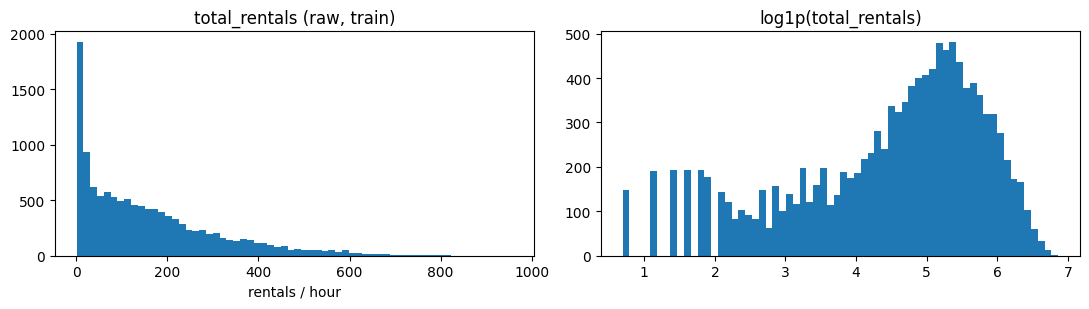

In [5]:
import matplotlib.pyplot as plt

# EDA on train: val/test kept untouched, so descriptive observations do not peek at the held-out data.
print("train: mean=%.2f  median=%.0f  max=%d  zeros=%.1f%%  skew=%.2f"
      % (y_train.mean(), y_train.median(), y_train.max(), (y_train == 0).mean() * 100, y_train.skew()))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].hist(y_train, bins=64); ax[0].set_title("total_rentals (raw, train)"); ax[0].set_xlabel("rentals / hour")
ax[1].hist(np.log1p(y_train), bins=64); ax[1].set_title("log1p(total_rentals)")
plt.tight_layout(); plt.show()

### Pipeline

Feature representation — for the linear model, inside a `ColumnTransformer` (a wrapper over `hourly_total`, not a new dataset):

- `hour_of_day`, `month`, `day_of_week` → **cyclic (sin/cos)**, otherwise 23:00 and 00:00 are "far apart";
- numeric (`conditions` ordinal, weather, `days_since_launch`) → **StandardScaler**;
- binary (`is_weekend`, `is_holiday`) → passthrough.

`make_linear(estimator)` builds any linear model on top of this preprocessor; `log_target` wraps the target in log1p/expm1. Learned transforms are fit only on the train fold — no leakage.

In [6]:
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler


def cyclic(period):
    """sin/cos encoding of a cyclic feature with the given period."""
    return FunctionTransformer(
        lambda x, p=period: np.column_stack([np.sin(2 * np.pi * x / p), np.cos(2 * np.pi * x / p)]),
        feature_names_out="one-to-one",
    )


preprocess = ColumnTransformer([
    ("hour",  cyclic(24), ["hour_of_day"]),
    ("month", cyclic(12), ["month"]),
    ("dow",   cyclic(7),  ["day_of_week"]),
    ("num",   StandardScaler(), ["conditions", "temperature_c", "perceived_temperature_c",
                                 "humidity", "windspeed_kmh", "days_since_launch"]),
    ("bin",   "passthrough", ["is_weekend", "is_holiday"]),
])


def make_linear(estimator, log_target=False):
    """Linear model on top of preprocess; log_target=True wraps the target in log1p/expm1."""
    pipe = Pipeline([("pre", preprocess), ("model", estimator)])
    if log_target:
        return TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)
    return pipe

### Training and metrics

The set: **MAE** (interpretable — "missing by N rentals/hour"), **RMSE** (penalises large misses),
**R²** (share of variance explained), **RMSE/MAE** (tail diagnostic: ≈1 uniform, >>1 there are spikes).
Baseline — `LinearRegression`. We train on **train**, measure on **validation** (test kept until the end).
The comparison is against a naive baseline (train mean). Predictions are clipped at zero from below.

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2_score(y_true, y_pred), "RMSE/MAE": rmse / mae}


baseline = make_linear(LinearRegression())   # raw target (justified below)
baseline.fit(X_train, y_train)
val_pred = np.clip(baseline.predict(X_val), 0, None)

results = pd.DataFrame({
    "LinearRegression (val)": evaluate(y_val, val_pred),
    "mean-baseline":          evaluate(y_val, np.full(len(y_val), y_train.mean())),
}).T
results.round(3)

,MAE,RMSE,R2,RMSE/MAE
LinearRegression (val),138.953,174.53,0.389,1.256
mean-baseline,194.135,253.97,-0.294,1.308


### Log target vs raw

The target is skewed → a standard hypothesis is to try `log1p` (multiplicative growth → additive). We check it: we change only the target, the model and split are fixed.

In [8]:
rows = {}
for name, log in [("raw target", False), ("log1p target", True)]:
    m = make_linear(LinearRegression(), log_target=log)
    m.fit(X_train, y_train)
    p = np.clip(m.predict(X_val), 0, None)
    rows[name] = evaluate(y_val, p)
pd.DataFrame(rows).T.round(3)

,MAE,RMSE,R2,RMSE/MAE
raw target,138.953,174.530,0.389,1.256
log1p target,175.852,259.854,-0.355,1.478


**Conclusion:** raw is clearly better — R²≈0.39 vs log1p <0 → **we stay with raw**. The linear model's weakness here is the nonlinearity of the daily curve, not the skew; the log only smears it more.

### Error breakdown (validation)

The global MAE hides the trouble spots. We look by hour of day: where exactly the linear model misses (peaks vs trough).

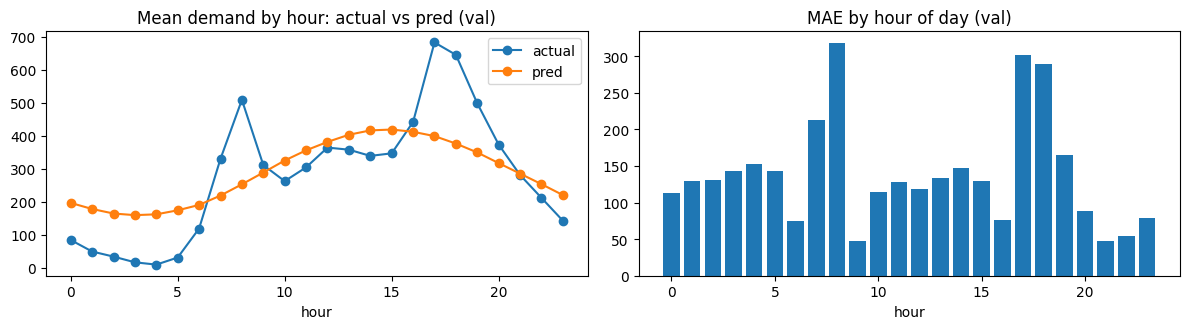

MAE by hour (worst):
hour_of_day
8     317.9
17    301.0
18    289.0
7     212.3


In [9]:
val_eval = val.assign(pred=val_pred, abs_err=np.abs(y_val.values - val_pred))

by_hour = val_eval.groupby("hour_of_day").agg(
    MAE=("abs_err", "mean"), actual=(TARGET, "mean"), pred=("pred", "mean"))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].plot(by_hour.index, by_hour["actual"], marker="o", label="actual")
ax[0].plot(by_hour.index, by_hour["pred"], marker="o", label="pred")
ax[0].set_title("Mean demand by hour: actual vs pred (val)"); ax[0].set_xlabel("hour"); ax[0].legend()
ax[1].bar(by_hour.index, by_hour["MAE"])
ax[1].set_title("MAE by hour of day (val)"); ax[1].set_xlabel("hour")
plt.tight_layout(); plt.show()

print("MAE by hour (worst):")
print(by_hour["MAE"].sort_values(ascending=False).head(4).round(1).to_string())

## Baseline conclusions

---

- **The linear model clearly beats the naive forecast** (val R²≈0.39 vs negative for "always the mean"; MAE ~139 vs ~194): it captures hour, season, trend and weather.
- **But there is a systematic miss.** RMSE/MAE ≈ 1.26 indicates a heavy error tail: the model underestimates the daytime peaks (8:00 and 17–18:00) and overestimates the night trough (at 3:00 it predicts ~160 against an actual ~17). The daily curve is too sharp for a pair of sin/cos terms — this is nonlinearity and interactions (hour × season, hour × weather).
- **The log target** loses to raw on all metrics → we stay with raw.
- **We did not touch test** — we will compute it once, after the model is chosen.

Next — "Improvements": one change per round, compared on validation.

## Improvements

---

Each step changes **one thing per round**, compared on **validation** (test untouched). The order is "simple → harder"; we add complexity only if the result justifies it.

### #1. Regularization: Ridge

With **n ≫ p** (~12k train rows vs ~16 features after cyclic) there is nothing for regularization to shrink → we expect a no-op. A quick check on validation:

In [10]:
rows = {}
for name, est in [("LinearRegression", LinearRegression()),
                  ("Ridge(alpha=1)",   Ridge(alpha=1.0)),
                  ("Ridge(alpha=10)",  Ridge(alpha=10.0))]:
    m = make_linear(est)
    m.fit(X_train, y_train)
    rows[name] = evaluate(y_val, np.clip(m.predict(X_val), 0, None))
pd.DataFrame(rows).T.round(3)

,MAE,RMSE,R2,RMSE/MAE
LinearRegression,138.953,174.530,0.389,1.256
Ridge(alpha=1),138.957,174.534,0.389,1.256
Ridge(alpha=10),138.987,174.575,0.388,1.256


Practically identical even at alpha=10 (differences in the 4th decimal) → with **n ≫ p** there is nothing for regularization to shrink, so the `LinearRegression` baseline stays. The real weakness is the underestimated peaks and overestimated trough (nonlinearity) → next, trees: **#3 `RandomForestRegressor`**, **#4 `HistGradientBoostingRegressor`**.

### #2. Encoding `conditions`: ordinal vs one-hot

The ordinal encoding (0..3 + scaler) imposes an **equal step** between weather states on the linear model
(clear→clouds = light_rain→heavy_rain). One-hot removes that assumption — a separate coefficient per state.
We check whether it is justified. (`heavy_rain` is rare: only 3 hours in the whole dataset.)

In [11]:
# Two preprocessor variants that differ only in how conditions is handled.
WEATHER_NUM = ["temperature_c", "perceived_temperature_c", "humidity", "windspeed_kmh", "days_since_launch"]
common = [
    ("hour",  cyclic(24), ["hour_of_day"]),
    ("month", cyclic(12), ["month"]),
    ("dow",   cyclic(7),  ["day_of_week"]),
    ("bin",   "passthrough", ["is_weekend", "is_holiday"]),
]


def preprocess_conditions(mode):
    if mode == "ordinal":
        steps = common + [("num", StandardScaler(), WEATHER_NUM + ["conditions"])]
    else:  # one-hot
        steps = common + [("num", StandardScaler(), WEATHER_NUM),
                          ("cond", OneHotEncoder(handle_unknown="ignore"), ["conditions"])]
    return ColumnTransformer(steps)


rows = {}
for mode in ["ordinal", "one-hot"]:
    m = Pipeline([("pre", preprocess_conditions(mode)), ("model", LinearRegression())])
    m.fit(X_train, y_train)
    rows[f"conditions = {mode}"] = evaluate(y_val, np.clip(m.predict(X_val), 0, None))
pd.DataFrame(rows).T.round(3)

,MAE,RMSE,R2,RMSE/MAE
conditions = ordinal,138.953,174.530,0.389,1.256
conditions = one-hot,138.952,174.264,0.391,1.254


**Conclusion:** one-hot gives **+0.002 R²** — within noise: weather is a weak feature next to hour/season,
and the equal-step assumption almost holds here. The `heavy_rain` column is trained on 3 rare hours —
dead weight. → we keep the **ordinal** encoding (simpler, equivalent in quality). For trees (#3/#4) the encoding does not matter — ordinal is fine for them.

### #3. Nonlinearity and interactions: RandomForest

The baseline captures the overall level but misses the shape of the day (peaks and the night trough) — the linear model lacks nonlinearity and interactions (`hour × season`, `hour × weather`). A tree gets them for free. We change **only the model**, the features and split stay the same. A tree needs no preprocessing: the `ColumnTransformer` with cyclic/scaling was for the linear model, while RandomForest works directly on the integer features.

In [12]:
from sklearn.ensemble import RandomForestRegressor

# Trees do not need the ColumnTransformer: raw integers, RF builds the interactions itself.
rf = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
rf_pred = np.clip(rf.predict(X_val), 0, None)

rows = {
    "LinearRegression (baseline)": evaluate(y_val, np.clip(baseline.predict(X_val), 0, None)),
    "RandomForest":                evaluate(y_val, rf_pred),
}
pd.DataFrame(rows).T.round(3)

,MAE,RMSE,R2,RMSE/MAE
LinearRegression (baseline),138.953,174.530,0.389,1.256
RandomForest,49.142,79.367,0.874,1.615


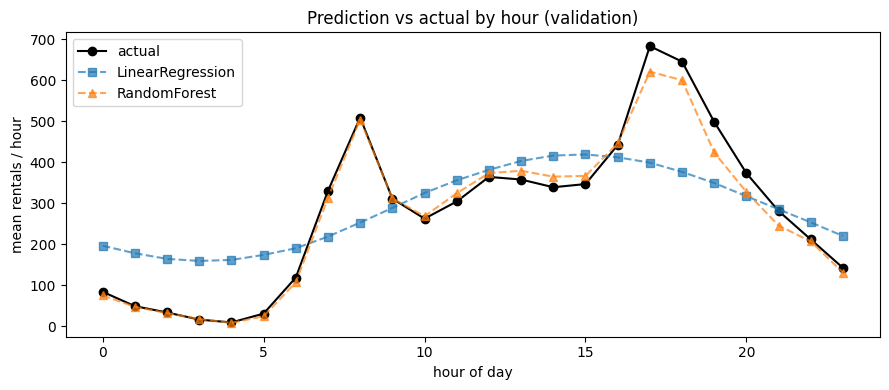

In [13]:
# Hourly profile: does RF capture the morning and evening peaks the baseline underestimated?
by_hour = (val.assign(LR=np.clip(baseline.predict(X_val), 0, None), RF=rf_pred)
              .groupby("hour_of_day")[[TARGET, "LR", "RF"]].mean())

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(by_hour.index, by_hour[TARGET], "o-", color="black", label="actual")
ax.plot(by_hour.index, by_hour["LR"], "s--", alpha=0.7, label="LinearRegression")
ax.plot(by_hour.index, by_hour["RF"], "^--", alpha=0.7, label="RandomForest")
ax.set_xlabel("hour of day")
ax.set_ylabel("mean rentals / hour")
ax.set_title("Prediction vs actual by hour (validation)")
ax.legend()
plt.tight_layout(); plt.show()

**Conclusion:** RandomForest gives a big jump — exactly on the weakness the baseline showed.

- **R² 0.39 → 0.87, MAE ~139 → ~49, RMSE ~175 → ~80** (validation), and without tuning, on default hyperparameters.
- The plot shows it: the morning (8:00) and evening (17–18:00) peaks the linear model cut off are restored by RF (8:00 — actual ~509, was ~253, now ~504). The night trough is no longer overestimated (3:00 — actual ~17, was ~160, now ~18).
- `RMSE/MAE` grew (1.26 → 1.61): the average error fell more than the peak error. The remaining error is now in rare spikes, not in a systematic miss of the daily shape.
- Feature importance: `hour_of_day` dominates (≈0.60), followed by the trend `days_since_launch` and temperature — consistent with the EDA.

Next step — **#4 `HistGradientBoosting`** (boosting): it builds trees sequentially, correcting errors, usually a bit more accurate.

### #4. Boosting: HistGradientBoosting

RandomForest averages independent trees; **boosting** builds them sequentially, each correcting the
previous ones' errors — usually more accurate on tabular data. We take `HistGradientBoostingRegressor`
(histogram-based, the same family as XGBoost/LightGBM): it is **native in sklearn** and pulls in no external
dependencies. XGBoost would give the same class of model, but on macOS it needs the system OpenMP (`libomp`) —
an extra blocker for an equivalent result. We change only the model; trees need no preprocessing.

In [14]:
from sklearn.ensemble import HistGradientBoostingRegressor

# Trees need no preprocessing — raw integers. Default hyperparameters, no tuning.
hgb = HistGradientBoostingRegressor(random_state=42)
hgb.fit(X_train, y_train)
hgb_pred = np.clip(hgb.predict(X_val), 0, None)

rows = {
    "LinearRegression":     evaluate(y_val, np.clip(baseline.predict(X_val), 0, None)),
    "RandomForest":         evaluate(y_val, rf_pred),
    "HistGradientBoosting": evaluate(y_val, hgb_pred),
}
pd.DataFrame(rows).T.round(3)

,MAE,RMSE,R2,RMSE/MAE
LinearRegression,138.953,174.530,0.389,1.256
RandomForest,49.142,79.367,0.874,1.615
HistGradientBoosting,50.428,73.390,0.892,1.455


**Conclusion:** HistGradientBoosting edges out RF on validation — **R² 0.874 → 0.892**, RMSE 79.4 → 73.4. `RMSE/MAE` fell (1.61 → 1.45): boosting evened out the error, the tail on hard hours got shorter. MAE barely changed (~49 → ~50). More iterations (500) make it worse (overfitting) — the default is better. → this is the **chosen model**, selection on validation is done.

### #5. Feature ablation: remove `perceived_temperature_c`?

The model is chosen (HGB) — we check whether its features can be simplified. [exploration_weather](exploration_weather.ipynb) showed corr **0.99**
between `temperature_c` and `perceived_temperature_c` → it looks redundant. But we cannot decide by correlation "by eye" —
we drop the feature and measure on validation (model/split fixed). For a linear model collinearity is theoretically harmful, for trees it is not.

In [15]:
# Remove perceived_temperature_c? corr 0.99 with temperature_c (see exploration_weather) — looks redundant.
FEATURES_REDUCED = [f for f in FEATURES if f != "perceived_temperature_c"]

# for the linear model — a preprocessor without perceived (the rest as in baseline)
preprocess_reduced = ColumnTransformer([
    ("hour",  cyclic(24), ["hour_of_day"]),
    ("month", cyclic(12), ["month"]),
    ("dow",   cyclic(7),  ["day_of_week"]),
    ("num",   StandardScaler(), ["conditions", "temperature_c", "humidity", "windspeed_kmh", "days_since_launch"]),
    ("bin",   "passthrough", ["is_weekend", "is_holiday"]),
])

rows = {}
for tag, pre in [("full", preprocess), ("no perceived", preprocess_reduced)]:
    m = Pipeline([("pre", pre), ("model", LinearRegression())]).fit(X_train, y_train)
    rows[f"LinearRegression ({tag})"] = evaluate(y_val, np.clip(m.predict(X_val), 0, None))
for tag, feats in [("full", FEATURES), ("no perceived", FEATURES_REDUCED)]:
    m = HistGradientBoostingRegressor(random_state=42).fit(train[feats], y_train)
    rows[f"HistGB ({tag})"] = evaluate(y_val, np.clip(m.predict(val[feats]), 0, None))
pd.DataFrame(rows).T.round(3)

,MAE,RMSE,R2,RMSE/MAE
LinearRegression (full),138.953,174.530,0.389,1.256
LinearRegression (no perceived),139.357,174.626,0.388,1.253
HistGB (full),50.428,73.390,0.892,1.455
HistGB (no perceived),53.780,77.597,0.879,1.443


**Conclusion — we keep `perceived_temperature_c`.** The 0.99 correlation was misleading. For the linear model removing it is almost neutral (a collinear duplicate, the predictions are the same: R² 0.389 → 0.388). But for the chosen HGB removing it drops **R² 0.892 → 0.879** (RMSE 73.4 → 77.6). The ~1% of variance that does not coincide with `temperature_c` is the "feels-like" correction (wind, humidity; a difference up to ~13°C), and the tree extracts signal from it. So we **leave the feature alone**. The lesson: redundancy is settled by an experiment (ablation), not by correlation — same as with holidays.

## Robustness check: time-series CV

---

The selection above is on **one** validation fold (summer 2012), which is seasonally narrow. Before going to test, we check
the robustness of the choice: a 5-fold `TimeSeriesSplit` on train+val (test kept aside) — train on the past,
measure on the next window, average over folds. This is a reliability check, not new tuning.

In [16]:
from sklearn.model_selection import TimeSeriesSplit, cross_validate

# TS-CV on train+val (test kept aside). Rows are already sorted by time → an expanding window.
dev = ds[ds["datetime_hourly"] < cut2]
X_dev, y_dev = dev[FEATURES], dev[TARGET]

tscv = TimeSeriesSplit(n_splits=5)
scoring = {"MAE": "neg_mean_absolute_error", "RMSE": "neg_root_mean_squared_error", "R2": "r2"}
models = {
    "LinearRegression":     make_linear(LinearRegression()),
    "RandomForest":         RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42),
}

rows = {}
for name, est in models.items():
    cv = cross_validate(est, X_dev, y_dev, cv=tscv, scoring=scoring)
    rows[name] = {"MAE": -cv["test_MAE"].mean(), "RMSE": -cv["test_RMSE"].mean(),
                  "R2 (mean)": cv["test_R2"].mean(), "R2 (std)": cv["test_R2"].std()}
pd.DataFrame(rows).T.round(3)

,MAE,RMSE,R2 (mean),R2 (std)
LinearRegression,108.704,141.182,0.264,0.130
RandomForest,51.931,79.024,0.760,0.089
HistGradientBoosting,50.062,74.111,0.777,0.139


**Conclusion:** the choice is robust. Averaged over 5 folds — **HGB R² ≈ 0.78, RF ≈ 0.76, LR ≈ 0.26**: the order is the same as on the single validation, HGB still slightly ahead (and on MAE/RMSE).

But what matters more: **the spread between folds is large** (R² std: RF 0.09, HGB 0.14 — HGB has a weak early fold ~0.52, where there is little data), and it is **much larger than the HGB–RF gap (~0.02)**. So this gap is **not significant**: on another window the leader could swap — that would be fold randomness, not a real change of leader. HGB stays a defensible choice, RF is a close and slightly more stable alternative. Trees are much better than the linear model on all folds.

## Final: evaluation on test

---

Model selection is done — on validation **HistGradientBoosting** won. Now a **single** run on the held-out
**test** (late 2012, autumn/winter). This is an honest estimate of generalization; we make no more decisions based on test.

In [17]:
# Single run on test: models trained on train, predicting on the held-out test.
rows = {
    "LinearRegression":     evaluate(y_test, np.clip(baseline.predict(X_test), 0, None)),
    "RandomForest":         evaluate(y_test, np.clip(rf.predict(X_test), 0, None)),
    "HistGradientBoosting": evaluate(y_test, np.clip(hgb.predict(X_test), 0, None)),
}
pd.DataFrame(rows).T.round(3)

,MAE,RMSE,R2,RMSE/MAE
LinearRegression,123.587,165.257,0.410,1.337
RandomForest,53.130,80.671,0.859,1.518
HistGradientBoosting,59.245,85.804,0.841,1.448


**Conclusion (test):**

- **HistGradientBoosting on test: R² ≈ 0.84, MAE ≈ 59, RMSE ≈ 86** — it confidently explains hourly demand (a naive forecast would give R²≈0).
- **The RF/HGB order flipped on test:** on validation HGB was ahead, on test RF is slightly ahead (0.859 vs 0.841). The ~0.02 difference is exactly the weakness of a single window (validation = summer, test = winter). We cannot re-select the model by test (that is leakage) — we keep HGB, chosen by the protocol. One more argument for TS-CV.
- The linear baseline is a bit better on test than on validation (R² 0.41), but still far behind the trees.

In Dagster we take the `Pipeline` of the chosen model; in production — retrain on all the data.